# Cardiac Arrhythmia Classification — Final Report

This project classifies ECG feature vectors into arrhythmia types using the UCI Arrhythmia dataset. The workflow focuses on leakage-safe preprocessing, class imbalance handling, and final held-out test evaluation so the reported results are realistic.

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

from milestone_02_split_and_impute import (
    load_arrhythmia_data,
    split_features_target,
    merge_rare_classes,
    split_train_test,
    fit_and_apply_imputer,
)

## Data Preparation

Rare classes 7, 8, 9, 14, and 15 were merged into class 99 because they had too few samples for reliable stratification.

In [20]:
df = load_arrhythmia_data()
X, y = split_features_target(df)

rare_labels = [7, 8, 9, 14, 15]
y = merge_rare_classes(y, rare_labels, 99)

X_train, X_test, y_train, y_test = split_train_test(X, y)
X_train_imputed, X_test_imputed = fit_and_apply_imputer(X_train, X_test)

print("X_train shape:", X_train_imputed.shape)
print("X_test shape:", X_test_imputed.shape)

X_train shape: (361, 279)
X_test shape: (91, 279)


## Final Model

The selected model is Random Forest, tuned via GridSearchCV in Milestone 4, with hyperparameters `max_depth=10`, `min_samples_leaf=4`, `n_estimators=100`, and `class_weight="balanced"`.

In [21]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=4,
    random_state=42,
    class_weight="balanced",
)

model.fit(X_train_imputed, y_train)
y_pred = model.predict(X_test_imputed)

## Results

In [22]:
print("Accuracy:", (y_pred == y_test).mean())
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7142857142857143
              precision    recall  f1-score   support

           1       0.84      0.76      0.80        49
           2       0.62      0.89      0.73         9
           3       0.75      1.00      0.86         3
           4       0.50      1.00      0.67         3
           5       0.00      0.00      0.00         3
           6       0.80      0.80      0.80         5
          10       0.67      0.80      0.73        10
          16       0.33      0.25      0.29         4
          99       0.50      0.20      0.29         5

    accuracy                           0.71        91
   macro avg       0.56      0.63      0.57        91
weighted avg       0.71      0.71      0.70        91



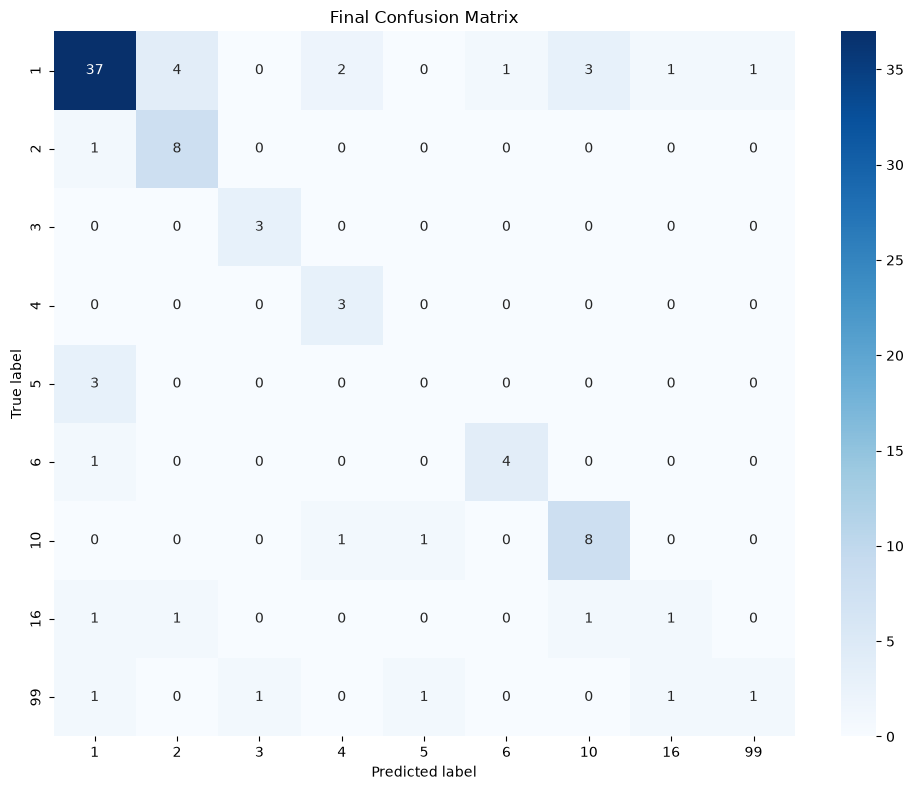

In [23]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Final Confusion Matrix")
plt.tight_layout()
plt.show()

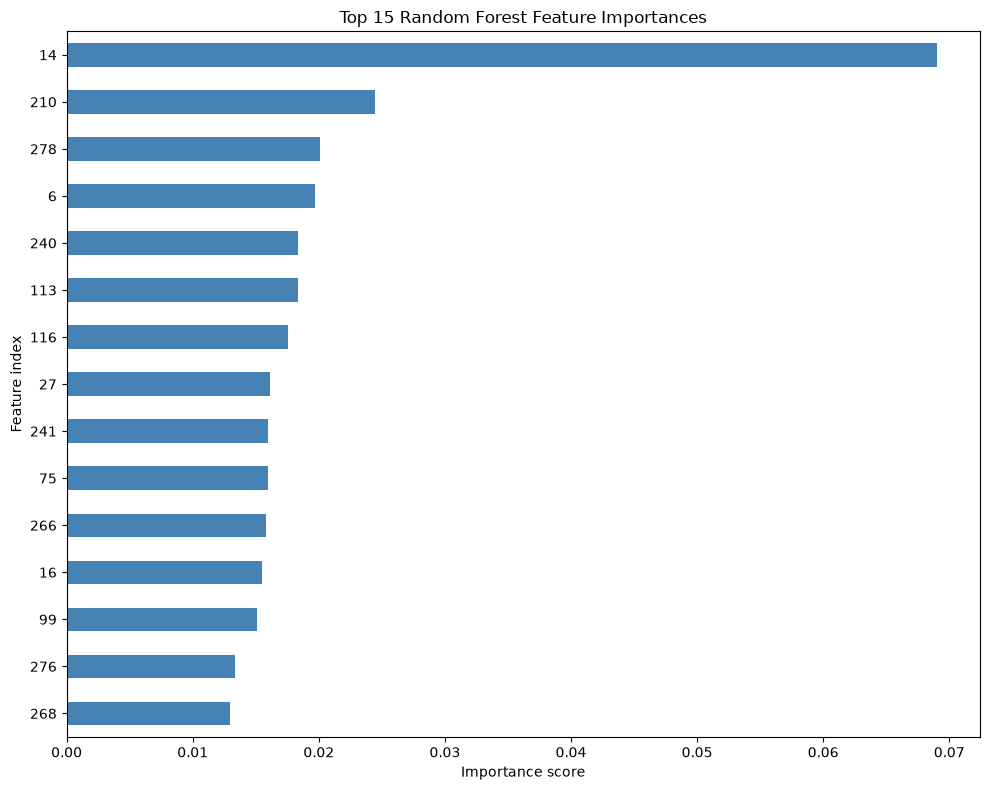

In [24]:
importances = pd.Series(model.feature_importances_, index=X_train_imputed.columns)
top_15 = importances.sort_values(ascending=False).head(15).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
top_15.plot(kind="barh", color="steelblue")
plt.xlabel("Importance score")
plt.ylabel("Feature index")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

## What Worked

- Rare class merging: Five arrhythmia classes (7, 8, 9, 14, 15) had only 2–9 samples each in the full dataset, making stratified splitting unreliable — some classes were entirely absent from either the train or test fold. Merging them into a single "other_arrhythmia" class (99, 23 total samples) ensured all classes were represented in both folds and made evaluation meaningful across the board.

- class_weight="balanced": The baseline Random Forest defaulted to predicting the majority class (class 1, "normal") when uncertain, since it made up over half the training data. Applying class_weight="balanced" improved minority-class recall substantially — for example, class 2 recall rose from 0.56 to 0.89 and class 6 from 0.20 to 0.80 — with only a marginal change in overall accuracy.

- Hyperparameter tuning: GridSearchCV over max_depth, min_samples_leaf, and n_estimators improved Random Forest's cross-validated macro-F1 from 0.611 to 0.637. Notably, the tuned model preferred a capped depth (10, not unlimited) and fewer trees (100, not 300) than the defaults — suggesting the untuned model was mildly overfitting on this small dataset, and constraining complexity generalized better.

## What Didn't Work

- PCA + SMOTE: Reducing to 70 principal components (90% explained variance) and oversampling minority classes with SMOTE initially looked like a major improvement (cross-validated macro-F1 up to 0.98). This turned out to be data leakage: SMOTE was applied once to the full training set before cross-validation, so synthetic points generated from a real sample could land in a different CV fold than that sample, letting the model "recognize" near-duplicates of its own training data during validation. After moving SMOTE inside each CV fold using an imblearn pipeline (the correct approach), cross-validated macro-F1 dropped to 0.40 — below the plain baseline (0.611). Likely causes: PCA discards ~10% of variance that may disproportionately contain the specific signal separating rare classes, and SMOTE had very few real points to interpolate from for classes with under 20 training samples, producing synthetic points that didn't generalize. This was a genuine, evaluated negative result, not an implementation error.

## Limitations

- Dataset size: 452 total instances against 279 features is a difficult ratio for any model — the risk of overfitting is high, and the final model's real-world generalization should be treated cautiously.
- Classes with too few samples: Even after merging rare classes, classes 5 (13 samples) and 16 (22 samples) remained near-zero in precision/recall throughout every experiment, including after tuning. This is a data limitation, not a modeling failure — no amount of tuning or resampling reliably fixes a class with fewer than ~15–20 real examples.
- Not for clinical use: This project is a coursework/portfolio exercise using tabular, feature-derived data (not raw ECG waveforms) and has not been validated against clinical standards. It should not be interpreted as a diagnostic tool, per the project's original scope.

## Conclusion

This project set out to classify ECG-derived features into arrhythmia types using the UCI Arrhythmia dataset, with an emphasis on handling high-dimensional, small-sample, imbalanced tabular data rather than on ML fundamentals. The final model — a Random Forest tuned via GridSearchCV, trained on merged classes with balanced class weighting — achieved a cross-validated macro-F1 of 0.637 and a held-out test accuracy of 0.714.

More valuable than the final number, though, was what the process revealed. Techniques that sound universally beneficial — PCA for dimensionality reduction, SMOTE for class imbalance — did not hold up under rigorous, leakage-free evaluation on this dataset, while a simpler combination (class weighting plus modest hyperparameter tuning) outperformed them. The gap between the two PCA+SMOTE results (0.98 CV macro-F1 when leaked, 0.40 when fixed) is itself one of the most important findings of the project: it's a concrete demonstration of how easily cross-validation can be silently invalidated, and why validating a pipeline's structure matters as much as validating its final score.

The model's heavy reliance on heart rate as its top predictive feature, combined with its persistent inability to classify the rarest classes (5 and 16) reliably, are honest signals of what this dataset can and cannot support — not something further tuning would resolve. Any extension of this work (more data, signal-level ECG features instead of summary statistics, or a binary "arrhythmia present/absent" reframing per the PRD's stretch goal) would be a more promising direction than further tuning of the current setup.

As a sanity check, Milestone 6 collapsed the problem to binary classification (arrhythmia present vs. absent) using the same tuned Random Forest configuration. This achieved a cross-validated macro-F1 of 0.786, notably higher than the 9-class model's 0.637. This gap confirms the pipeline itself is sound — the fine-grained model's lower score reflects the genuine difficulty of distinguishing between 9 overlapping, often small-sample arrhythmia classes, not an implementation issue. In a real diagnostic context, this suggests a two-stage approach (first detect presence, then classify type) might be more practical than a single 9-way classifier, though exploring that is beyond this project's scope.